# Save of NB State as of 4/5 afternoon (Last implemented adaptive resizing() function)

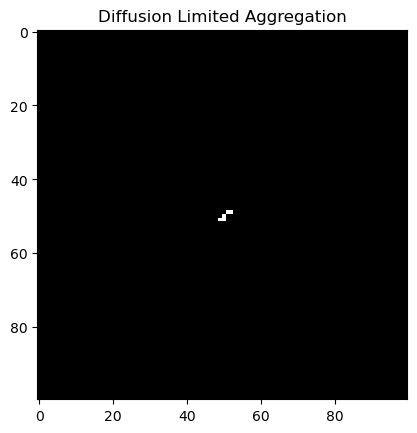

In [ ]:
# Project 4 - Diffusion Limited Aggregation
import numpy as np
import matplotlib.pyplot as plt

space = np.zeros((100, 100), dtype=bool)    # boolean array to represent discrete 2D space (100x100 blocks): True for occupied block, false for empty block
space[50, 50] = True                        # puts the seed in the middle

stickiness = 1                              # factor value between (0 to 1). The chance it has of sticking to the seed

seed = True

def random_walk():
    x, y = 0, 0
    while (True):                           # Loop until the particle sticks to seed
        # RANDOM WALK ALGORITHM
        direction = np.random.choice(['up', 'down', 'left', 'right'])
        if direction == 'up':
            y += 1
        elif direction == 'down':
            y -= 1
        elif direction == 'left':
            x -= 1
        elif direction == 'right':
            x += 1
        
        # Check if particle is next to the seed
        if (space[x-1:x+2, y-1:y+2].any()):
            # Chance of sticking to the seed is the stickiness factor
            if np.random.rand() < stickiness:
                space[x, y] = seed
            break


# DLA Simulation

N = 4 # number of particles
for i in range(N):
    random_walk()

# image plotting from matplotlib plots the space array
plt.imshow(space, cmap='gray')
plt.title('Diffusion Limited Aggregation')
plt.show()


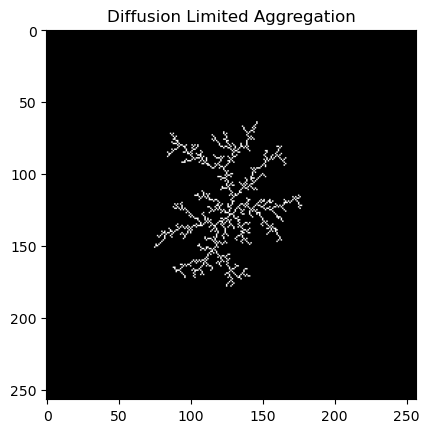

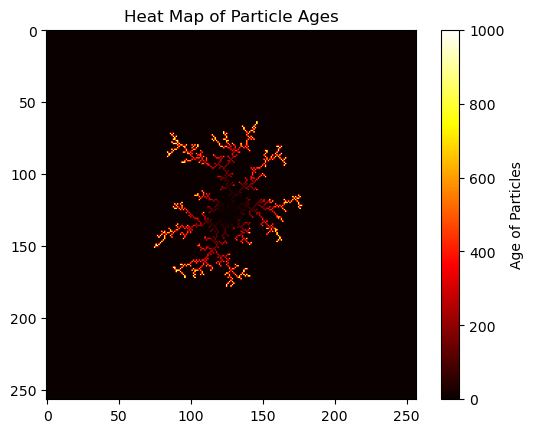

In [ ]:
# The runtime takes forever for more than 4 particles so I'm gonna copy and paste what I have above and try to make it more efficient.


# The runtime issue I was having was due to the particle wandering really far from the seed.
# A potential fix would be to reset it after it wanders too far from the seed.
# However, I think I came up with a better solution which is to apply periodic BCs
# This way it never wanders far and in the case where particles are starting uniformly from the edges,
# it will be the same scenario for large N

###################################################################
# ChangeLog: 

#4/4
# changed the space array to be 101x101 instead of 100x100 so the seed is actually in the middle
# moved the break statement inside the stick check so that it only breaks if the particle sticks
# added %100 to implement periodic BCs which should be the same as a "kill radius" but slightly more efficient

#4/5
# added heat map

#**********************************************************************

# Future changes:

# 1) The particle continues to wander if it doesn't stick which is realistic, however, it can penetrate the crystal and stick inside which I don't think is realistic.
#    I believe is should have to bounce off if it doesn't stick. 
#    If it penetrates, it would artificially effect the stickiness vs capacity dimension so it needs to be addressed.
# 2) Ideally I want length to be an optimal function of N. The two options I thought of:
#    a) use capacity dimension data to predict optimal length
#    b) adjust length adaptively as the crystal grows - implemented and works well

###################################################################
# Run log:
#
# 1)   N=1000, length = 201, no adaptive resizing (max r was about 60)
#      Runtime: 8 min and 4.3 s.
# 
# 2)   N=1000, start length = 51, adaptive resizing set to: length < 3r_max
#      Runtime: 2 min and 2.5 s.
#
# 3)   N=1000, start length = 51, adaptive resizing set to: length < 4r_max
#      Runtime: 5 min and 53.1 s.
#
###################################################################

import numpy as np
import matplotlib.pyplot as plt

length = 51                                # added length variable so I can change it easier (must be odd to have a center seed)


                                            # v changed 100 to 101 so the seed is actually centered
space = np.zeros((length, length), dtype=bool)    # boolean array to represent discrete 2D space (102x102 blocks): True for occupied block, false for empty block
space[length//2, length//2] = True                        # puts the seed in the middle

heat = np.zeros((length, length))                 # tracks age of particles

stickiness = 1                              # factor value between (0 to 1). The chance it has of sticking to the seed

seed = True

def resizing():
    ##############################################
    # Adaptive resizing
    global length, space, heat                                          # I should probably pass these later but rn Im just testing stuff

    r_max = np.max(np.abs(np.argwhere(space) - length//2)) + 1          # max distance from the center seed
    if length < 4 * r_max:                                              # condition to adjust length
        new_length = 4 * r_max
        if new_length % 2 == 0:                                         # ensures new length is odd so seed can remain centered
            new_length += 1

        new_space = np.zeros((new_length, new_length), dtype=bool)      # adjusts space to new length dimensions
        new_heat = np.zeros((new_length, new_length))                   # adjusts heat to new length dimensions

        shift = (new_length - length) // 2                              # shift such that the space expands outwards from center

        crystal_indices = np.argwhere(space)                            # ^ adjusts space such that it adds space outwards from center
        for x, y in crystal_indices:
            new_space[x + shift, y + shift] = True
            new_heat[x + shift, y + shift] = heat[x, y]
        
        length = new_length                                             # updates length
        space = new_space                                               # updates space
        heat = new_heat                                                 # updates heat

    ##############################################

def random_walk():

    resizing()

    edge = np.random.choice(['top', 'bottom', 'left', 'right'])                     # changed to start at a random point on the edges
    if edge == 'top':
        x, y = np.random.randint(0, length), length - 1
    elif edge == 'bottom':
        x, y = np.random.randint(0, length), 0
    elif edge == 'left':
        x, y = 0, np.random.randint(0, length)
    elif edge == 'right':
        x, y = length - 1, np.random.randint(0, length)

    while (True):                           # Loop until the particle sticks to seed
        # RANDOM WALK ALGORITHM
        direction = np.random.choice(['up', 'down', 'left', 'right'])
        if direction == 'up':
            y = (y + 1) % length
        elif direction == 'down':
            y = (y - 1) % length
        elif direction == 'left':
            x = (x - 1) % length
        elif direction == 'right':
            x = (x + 1) % length
        
        # Check if particle is next to the seed (3x3 neighborhood)
        if (space[x-1:x+2, y-1:y+2].any()):                                 # Starts at x-1 and goes up to but not including x+2.
            # Chance of sticking to the seed is the stickiness factor
            if np.random.rand() < stickiness:
                space[x, y] = seed
                heat[x, y] = i + 1                                          # tracks the age of the particle that sticks to the seed
                break                                                       # moved break inside the if so it only breaks if the particle sticks


# DLA Simulation

N = 1000 # number of particles
for i in range(N):
    random_walk()


# image plotting from matplotlib plots the space array
plt.imshow(space, cmap='gray')
plt.title('Diffusion Limited Aggregation')
plt.show()

# plot heat map
plt.imshow(heat, cmap='hot')
plt.title('Heat Map of Particle Ages')
plt.colorbar(label='Age of Particles')
plt.show()

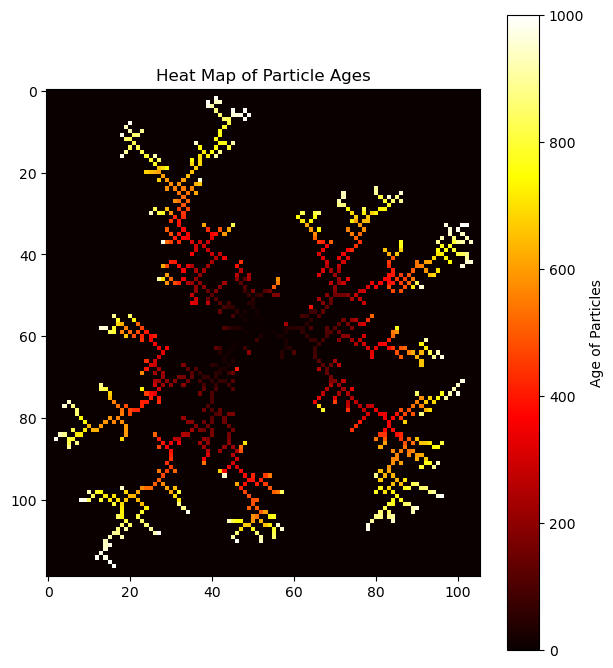

In [70]:
##### Crops the figure. Instructions also say might want to add heat map but I would need to change some code probably since I used a boolean array I need to think about it

#crystal = space.astype(int) 
crystal = heat


# sum columns and rows, identify which elements are not zero
xslice = np.where(np.sum(crystal,axis=0))[0]
yslice = np.where(np.sum(crystal,axis=1))[0]

# calculate the size of the cropped aggregate
whitespace = 2  # don't crop exactly to the edges of the DLA
ypixels = yslice[-1]-yslice[0]+2*whitespace
xpixels = xslice[-1]-xslice[0]+2*whitespace

# approximate the size of the generated figure. This is more than good enough almost always.
figure_ppi = 15  # ppi = pixels per inch
figw = xpixels/figure_ppi
figh = ypixels/figure_ppi+0.375  # add extra space for the figure title

# Create a figure/axis object (this makes systematic figure generation much easier)
# NB you should specify the length and width of the figure (in inches) here.
fig, ax = plt.subplots(figsize=(figw, figh))

# slice the "crystal" object on the edges identified with the "where" command.
# NB: you can break a python function call over multiple lines to make it easier to read
#_ = ax.imshow(crystal[yslice[0]-whitespace:yslice[-1]+whitespace+1,
#                      xslice[0]-whitespace:xslice[-1]+whitespace+1],
#               origin='upper',
#               interpolation='nearest',
#               aspect='equal', cmap='hot')  # changed to heat map

plt.imshow(crystal[yslice[0]-whitespace:yslice[-1]+whitespace+1, xslice[0]-whitespace:xslice[-1]+whitespace+1], cmap='hot')
plt.title('Heat Map of Particle Ages')
plt.colorbar(label='Age of Particles')
plt.show()


### Runtime Analysis Script Outline
```python
import time
import numpy as np


def run_simulation(N):
    ####
    #### 
    ####


N_array = [10, 100, ...]
for N in N_array
    trials = 20
    times = np.zeros(trials)

    for i in range(trials):
        t0 = time.perf_counter()
        run_simulation(N)
        t1 = time.perf_counter()
        times[i] = t1 - t0 

    print(f"Average runtime: {np.mean(times)} for N={N}")
    print(f"Std dev: {np.std(times)} for N={N}")
```

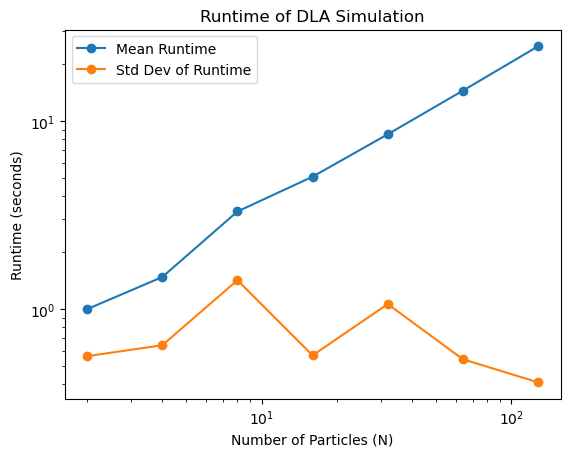

Estimated slope: 0.78


In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt

Mean_times = []                                                               # python arrays bc np arrays were being weird with appending
Std_dev = []                                                                  # ^


# runs the DLA simulation 
def run_simulation(N):
    global space                                                              # had to add "global space" because it wasn't resetting the cluster between runs
    space = np.zeros((101, 101), dtype=bool)
    space[50, 50] = True
    for i in range(N):
        random_walk()


N_array = [2, 4, 8, 16, 32, 64, 128]                                          # multiples of 2
trials_dictionary = {2: 10, 4: 10, 8: 8, 16: 6, 32: 4, 64: 2, 128: 2}         # dictionary for trials for each N (less trials for higher N so it doesn't take forever)

for N in N_array:

    trials = trials_dictionary[N]
    times = np.zeros(trials)

    for i in range(trials):
        t0 = time.perf_counter()                                              # starts clock
        run_simulation(N)                                                     # runs simulation
        t1 = time.perf_counter()                                              # ends clock
        times[i] = t1 - t0                                                    # stores runtime

    mean_time = np.mean(times)                                                # calculates mean runtime
    std_time = np.std(times)                                                  # calculates std dev of runtime

    #print(f"Average runtime: {mean_time:.6f} s for N = {N}")
    #print(f"Std dev: {std_time:.6f} s for N = {N}")

    Mean_times.append(mean_time)                                              # stores mean runtime
    Std_dev.append(std_time)                                                  # stores std dev of runtime


#print(Mean_times)
#print (N_array)

plt.loglog(N_array, Mean_times, marker='o', label='Mean Runtime')
plt.loglog(N_array, Std_dev, marker='o', label='Std Dev of Runtime')
plt.xlabel('Number of Particles (N)')
plt.ylabel('Runtime (seconds)')
plt.title('log-log Runtime of DLA Simulation')
plt.legend()
plt.show()
slope = np.polyfit(np.log(N_array), np.log(Mean_times), 1)[0]                 # fits the line with np.polyfit and gets the slope with [0]
print(f"Estimated slope: {slope:.2f}")


### Capacity Dimension Stuff

The next thing I need to do is figure out and understand what the capacity dimension and topological dimension refers to. After a quick google search, it says that it quantifies the space occupied by the cluster's mass distribution. Meanwhile, the instructions imply this changes with the stickiness factor. So, I guess am I supposed to kill the particle if it doesn't stick rather than letting it continue to wander? Instructions also say to try to replicate their published capacity dimension

### Periodic Boundary Conditions Summary
I'll want to explain why I chose periodic BCs in my writeup so I'm gonna write rough explanation:

Typically, when one simulates DLA he introduces a "kill radius" that resets the particle when it wonders outside a specified radius. This way the particle doesn't wander far away and take a long time to come back, which improves runtime. Periodic boundary conditions make the algorithm even more efficient as the particle doesn't even have a chance to run off. However, the dilemma is whether or not they change the physical scenario. If you are spawning in particles uniformly distributed around the edges, and the seed is centered in the space, then periodic boundary conditions accurately represent the same physical scenario for large N. The way one can think about this is that the starting position of the periodic BC scenario can be thought of as the last edge that the particle came from before it attached to the seed. In this case, the starting positions are uniformly distributed as they would be with the randomized starting positions + kill radius scenario.